In [1]:
!pip install stanza networkx matplotlib pandas -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.7/773.7 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 23.3 MB/s eta 0:00:00


In [2]:
import stanza

stanza.download("en")

INFO:stanza:Downloaded file to /root/.cache/stanza/1.12.0/resources/resources.json
INFO:stanza:Downloading default packages for language: en (English) ...


INFO:stanza:Downloaded file to /root/.cache/stanza/1.12.0/resources/en/default.zip
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.12.0/resources


[['zip', 'default.zip']]

### **1. Tạo pipeline dependency parser**

In [3]:
import stanza

nlp = stanza.Pipeline(
    lang="en",
    processors="tokenize,pos,lemma,depparse",
    use_gpu=True
)

INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.12.0/resources/resources.json
INFO:stanza:Loading these models for language: en (English):
| Processor | Package           |
---------------------------------
| tokenize  | combined          |
| mwt       | combined          |
| pos       | combined_charlm   |
| lemma     | combined_nocharlm |
| depparse  | combined_charlm   |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Loading: lemma
INFO:stanza:Loading: depparse
INFO:stanza:Done loading processors!


### **2. Parse một câu ví dụ**

In [4]:
sentence = "I prefer the morning flight through Denver."

doc = nlp(sentence)

for sent in doc.sentences:
    for word in sent.words:
        print(word.id, word.text, word.upos, word.head, word.deprel)

1 I PRON 2 nsubj
2 prefer VERB 0 root
3 the DET 5 det
4 morning NOUN 5 compound
5 flight NOUN 2 obj
6 through ADP 7 case
7 Denver PROPN 2 obl
8 . PUNCT 2 punct


### **3. Hiển thị dạng head → dependent**

In [5]:
for sent in doc.sentences:
    words = {word.id: word.text for word in sent.words}
    words[0] = "ROOT"

    for word in sent.words:
        head = words[word.head]
        dependent = word.text
        relation = word.deprel
        print(f"{head} → {dependent}    {relation}")

prefer → I    nsubj
ROOT → prefer    root
flight → the    det
flight → morning    compound
prefer → flight    obj
Denver → through    case
prefer → Denver    obl
prefer → .    punct


### **4. Minh họa dependency tree**

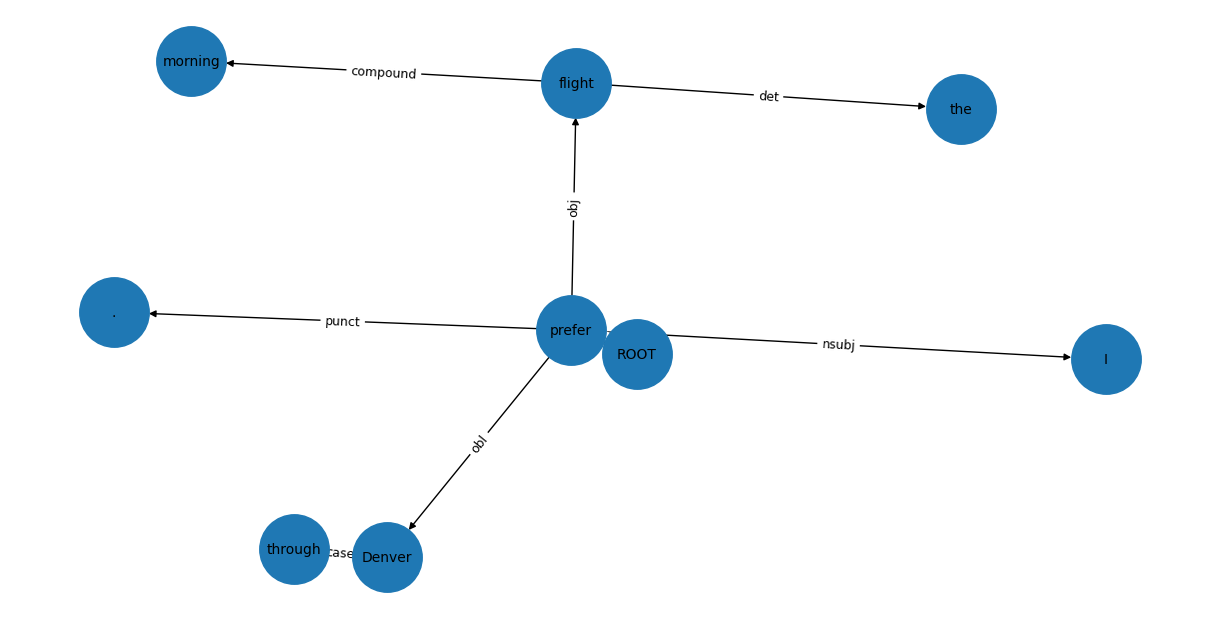

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

sent = doc.sentences[0]

G = nx.DiGraph()

words = {word.id: word.text for word in sent.words}
words[0] = "ROOT"

for word in sent.words:
    G.add_edge(words[word.head], word.text, label=word.deprel)

plt.figure(figsize=(12, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=2500, font_size=10, arrows=True)
edge_labels = nx.get_edge_attributes(G, "label")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)
plt.show()

### **5. Parse nhiều câu để xem các quan hệ dependency khác nhau**

In [7]:
sentences = [
    "United canceled the morning flights to Houston.",
    "Book me the flight through Houston.",
    "We flew to Denver and drove to Steamboat.",
    "The cheapest flight was delayed.",
    "JetBlue canceled our flight this morning which was already late."
]

for sentence in sentences:
    print("=" * 80)
    print(sentence)
    doc = nlp(sentence)

    for sent in doc.sentences:
        words = {word.id: word.text for word in sent.words}
        words[0] = "ROOT"

        for word in sent.words:
            print(f"{words[word.head]} → {word.text}    {word.deprel}")

United canceled the morning flights to Houston.
canceled → United    nsubj
ROOT → canceled    root
flights → the    det
flights → morning    compound
canceled → flights    obj
Houston → to    case
flights → Houston    nmod
canceled → .    punct
Book me the flight through Houston.
ROOT → Book    root
Book → me    iobj
flight → the    det
Book → flight    obj
Houston → through    case
flight → Houston    nmod
Book → .    punct
We flew to Denver and drove to Steamboat.
flew → We    nsubj
ROOT → flew    root
Denver → to    case
flew → Denver    obl
drove → and    cc
flew → drove    conj
Steamboat → to    case
drove → Steamboat    obl
flew → .    punct
The cheapest flight was delayed.
flight → The    det
flight → cheapest    amod
delayed → flight    nsubj:pass
delayed → was    aux:pass
ROOT → delayed    root
delayed → .    punct
JetBlue canceled our flight this morning which was already late.
canceled → JetBlue    nsubj
ROOT → canceled    root
flight → our    nmod:poss
canceled → flight    

### **6. Đưa dependency parse vào DataFrame**

In [8]:
import pandas as pd

sentence = "United canceled the morning flights to Houston."
doc = nlp(sentence)

rows = []

for sent in doc.sentences:
    words = {word.id: word.text for word in sent.words}
    words[0] = "ROOT"

    for word in sent.words:
        rows.append({
            "id": word.id,
            "word": word.text,
            "upos": word.upos,
            "head_id": word.head,
            "head_word": words[word.head],
            "dependency_relation": word.deprel
        })

df = pd.DataFrame(rows)
df

,id,word,upos,head_id,head_word,dependency_relation
0,1,United,VERB,2,canceled,nsubj
1,2,canceled,VERB,0,ROOT,root
2,3,the,DET,5,flights,det
3,4,morning,NOUN,5,flights,compound
4,5,flights,NOUN,2,canceled,obj
5,6,to,ADP,7,Houston,case
6,7,Houston,PROPN,5,flights,nmod
7,8,.,PUNCT,2,canceled,punct


### **7. Tạo gold parse thủ công**

In [9]:
sentence = "Book me the flight through Houston."
doc = nlp(sentence)

gold = {
    1: (0, "root"),
    2: (1, "iobj"),
    3: (4, "det"),
    4: (1, "obj"),
    5: (6, "case"),
    6: (4, "nmod"),
    7: (1, "punct")
}

system = {}

for sent in doc.sentences:
    for word in sent.words:
        system[word.id] = (word.head, word.deprel)

print("System parse:")
for sent in doc.sentences:
    words = {word.id: word.text for word in sent.words}
    words[0] = "ROOT"

    for word in sent.words:
        print(word.id, words[word.head], "→", word.text, word.deprel)

System parse:
1 ROOT → Book root
2 Book → me iobj
3 flight → the det
4 Book → flight obj
5 Houston → through case
6 flight → Houston nmod
7 Book → . punct


### **8. Tính UAS và LAS**

In [10]:
def compute_uas_las(gold, system):
    total = 0
    correct_head = 0
    correct_head_and_label = 0

    for word_id in gold:
        if word_id in system:
            total += 1

            gold_head, gold_label = gold[word_id]
            system_head, system_label = system[word_id]

            if gold_head == system_head:
                correct_head += 1

            if gold_head == system_head and gold_label == system_label:
                correct_head_and_label += 1

    uas = correct_head / total
    las = correct_head_and_label / total

    return uas, las

uas, las = compute_uas_las(gold, system)

print("UAS:", uas)
print("LAS:", las)

UAS: 1.0
LAS: 1.0


### **9. Xem token nào đúng/sa**

In [11]:
rows = []

for sent in doc.sentences:
    words = {word.id: word.text for word in sent.words}
    words[0] = "ROOT"

    for word in sent.words:
        gold_head, gold_label = gold[word.id]
        system_head, system_label = system[word.id]

        rows.append({
            "word": word.text,
            "gold_head": words.get(gold_head, "ROOT"),
            "system_head": words.get(system_head, "ROOT"),
            "gold_label": gold_label,
            "system_label": system_label,
            "UAS_correct": gold_head == system_head,
            "LAS_correct": gold_head == system_head and gold_label == system_label
        })

eval_df = pd.DataFrame(rows)
eval_df

,word,gold_head,system_head,gold_label,system_label,UAS_correct,LAS_correct
0,Book,ROOT,ROOT,root,root,True,True
1,me,Book,Book,iobj,iobj,True,True
2,the,flight,flight,det,det,True,True
3,flight,Book,Book,obj,obj,True,True
4,through,Houston,Houston,case,case,True,True
5,Houston,flight,flight,nmod,nmod,True,True
6,.,Book,Book,punct,punct,True,True


### **10. Demo ý tưởng transition-based parsing thủ công**

In [12]:
words = ["Book", "me", "the", "morning", "flight"]

stack = ["ROOT"]
buffer = words.copy()
relations = []

actions = [
    ("SHIFT", None),
    ("SHIFT", None),
    ("RIGHTARC", ("Book", "me", "iobj")),
    ("SHIFT", None),
    ("SHIFT", None),
    ("SHIFT", None),
    ("LEFTARC", ("flight", "morning", "compound")),
    ("LEFTARC", ("flight", "the", "det")),
    ("RIGHTARC", ("Book", "flight", "obj")),
    ("RIGHTARC", ("ROOT", "Book", "root"))
]

for step, (action, relation) in enumerate(actions):
    print("=" * 80)
    print("Step:", step)
    print("Before")
    print("Stack:", stack)
    print("Buffer:", buffer)
    print("Action:", action)

    if action == "SHIFT":
        stack.append(buffer.pop(0))

    elif action == "LEFTARC":
        head, dependent, label = relation
        relations.append(relation)
        stack.remove(dependent)

    elif action == "RIGHTARC":
        head, dependent, label = relation
        relations.append(relation)
        stack.remove(dependent)

    print("After")
    print("Stack:", stack)
    print("Buffer:", buffer)
    print("Relations:", relations)

Step: 0
Before
Stack: ['ROOT']
Buffer: ['Book', 'me', 'the', 'morning', 'flight']
Action: SHIFT
After
Stack: ['ROOT', 'Book']
Buffer: ['me', 'the', 'morning', 'flight']
Relations: []
Step: 1
Before
Stack: ['ROOT', 'Book']
Buffer: ['me', 'the', 'morning', 'flight']
Action: SHIFT
After
Stack: ['ROOT', 'Book', 'me']
Buffer: ['the', 'morning', 'flight']
Relations: []
Step: 2
Before
Stack: ['ROOT', 'Book', 'me']
Buffer: ['the', 'morning', 'flight']
Action: RIGHTARC
After
Stack: ['ROOT', 'Book']
Buffer: ['the', 'morning', 'flight']
Relations: [('Book', 'me', 'iobj')]
Step: 3
Before
Stack: ['ROOT', 'Book']
Buffer: ['the', 'morning', 'flight']
Action: SHIFT
After
Stack: ['ROOT', 'Book', 'the']
Buffer: ['morning', 'flight']
Relations: [('Book', 'me', 'iobj')]
Step: 4
Before
Stack: ['ROOT', 'Book', 'the']
Buffer: ['morning', 'flight']
Action: SHIFT
After
Stack: ['ROOT', 'Book', 'the', 'morning']
Buffer: ['flight']
Relations: [('Book', 'me', 'iobj')]
Step: 5
Before
Stack: ['ROOT', 'Book', 'the', 

### **11. Demo graph-based parsing bằng maximum spanning tree**

In [13]:
import networkx as nx

nodes = ["ROOT", "Book", "that", "flight"]

edges = [
    ("ROOT", "Book", 12),
    ("ROOT", "that", 4),
    ("ROOT", "flight", 4),
    ("Book", "that", 5),
    ("Book", "flight", 8),
    ("that", "Book", 6),
    ("that", "flight", 7),
    ("flight", "Book", 5),
    ("flight", "that", 7)
]

G = nx.DiGraph()

for head, dep, score in edges:
    G.add_edge(head, dep, weight=score)

mst = nx.maximum_spanning_arborescence(G)

print("Selected dependency edges:")
for head, dep, data in mst.edges(data=True):
    print(f"{head} → {dep}    score={data['weight']}")

Selected dependency edges:
ROOT → Book    score=12
Book → flight    score=8
flight → that    score=7


### **12. Vẽ graph-based result**

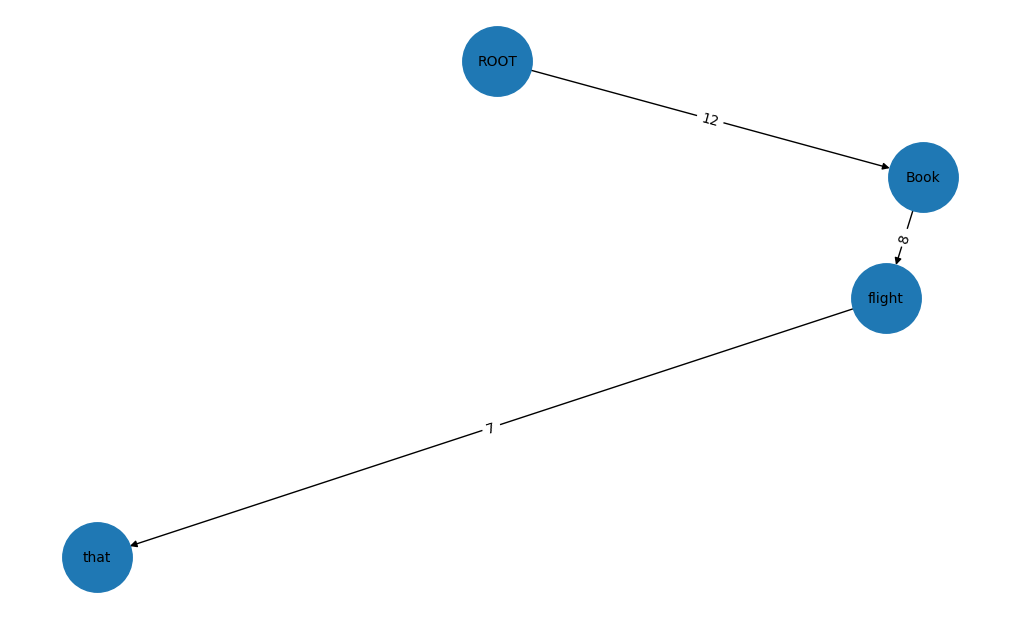

In [14]:
plt.figure(figsize=(10, 6))

pos = nx.spring_layout(mst, seed=42)
nx.draw(mst, pos, with_labels=True, node_size=2500, font_size=10, arrows=True)

edge_labels = nx.get_edge_attributes(mst, "weight")
nx.draw_networkx_edge_labels(mst, pos, edge_labels=edge_labels)

plt.show()

### **13. So sánh dependency parser trên nhiều câu bằng bảng**

In [15]:
all_rows = []

for sentence in sentences:
    doc = nlp(sentence)

    for sent in doc.sentences:
        words = {word.id: word.text for word in sent.words}
        words[0] = "ROOT"

        for word in sent.words:
            all_rows.append({
                "sentence": sentence,
                "word": word.text,
                "upos": word.upos,
                "head": words[word.head],
                "relation": word.deprel
            })

all_df = pd.DataFrame(all_rows)
all_df

,sentence,word,upos,head,relation
0,United canceled the morning flights to Houston.,United,VERB,canceled,nsubj
1,United canceled the morning flights to Houston.,canceled,VERB,ROOT,root
2,United canceled the morning flights to Houston.,the,DET,flights,det
3,United canceled the morning flights to Houston.,morning,NOUN,flights,compound
4,United canceled the morning flights to Houston.,flights,NOUN,canceled,obj
5,United canceled the morning flights to Houston.,to,ADP,Houston,case
6,United canceled the morning flights to Houston.,Houston,PROPN,flights,nmod
7,United canceled the morning flights to Houston.,.,PUNCT,canceled,punct
8,Book me the flight through Houston.,Book,VERB,ROOT,root
9,Book me the flight through Houston.,me,PRON,Book,iobj


### **14. Đếm số lần xuất hiện từng dependency relation**

In [16]:
relation_counts = all_df["relation"].value_counts().reset_index()
relation_counts.columns = ["dependency_relation", "count"]
relation_counts

,dependency_relation,count
0,root,5
1,punct,5
2,det,4
3,nsubj,4
4,case,4
5,obj,3
6,obl,2
7,nmod,2
8,compound,1
9,iobj,1
